# Deep Learning - Évaluation 1
## Classification d'images CIFAR-100 avec MLP et CNN

## Ce que nous développons dans le projet

1. [Chargement des données](#section1)
2. [Exploration du dataset CIFAR-100](#section2)
3. [Modèle MLP (Multi-Layer Perceptron)](#section3)
4. [Modèle CNN (Convolutional Neural Network)](#section4)
5. [Comparaison et analyse des résultats](#section5)
6. [Conclusion](#section6)

<a id='section1'></a>
## 1. Introduction et chargement des données

### Objectif
Comparer deux architectures de deep learning (MLP et CNN) pour classifier 100 catégories d'objets du dataset CIFAR-100.

### Dataset CIFAR-100
- **Images** : 32×32 pixels en couleur (RGB)
- **Classes** : 100 catégories (animaux, véhicules, objets, plantes, etc.)
- **Entraînement** : 50,000 images (500 par classe)
- **Test** : 10,000 images (100 par classe)
- **Difficulté** : Dataset complexe, plus difficile que CIFAR-10

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from keras import models, layers, callbacks
from keras.datasets import cifar100
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [5]:
# chargement du dataset
(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode='fine')

y_train = y_train.flatten()
y_test = y_test.flatten()

<a id='section2'></a>
## 2. Exploration du dataset CIFAR-100

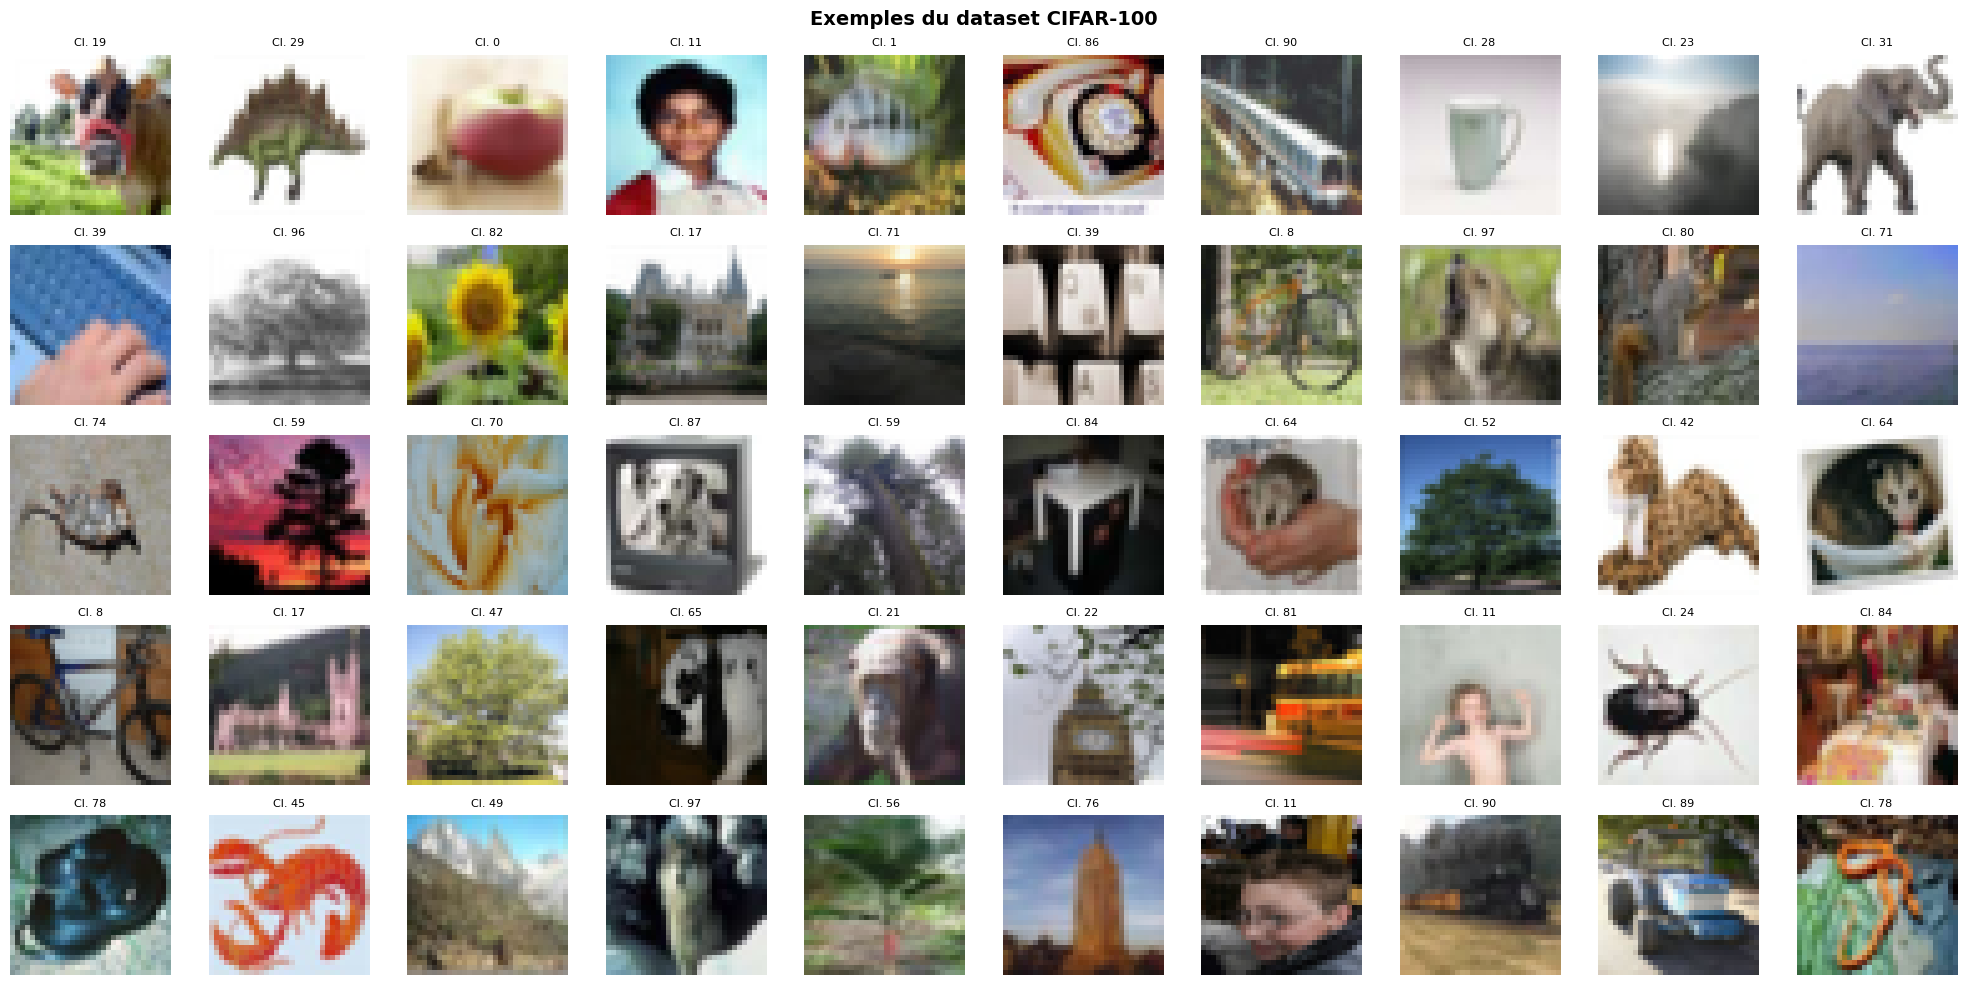

In [6]:
# quelques exemples pour voir à quoi ressemble le dataset
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(f"Cl. {y_train[i]}", fontsize=8)
    ax.axis('off')

plt.suptitle('Exemples du dataset CIFAR-100', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

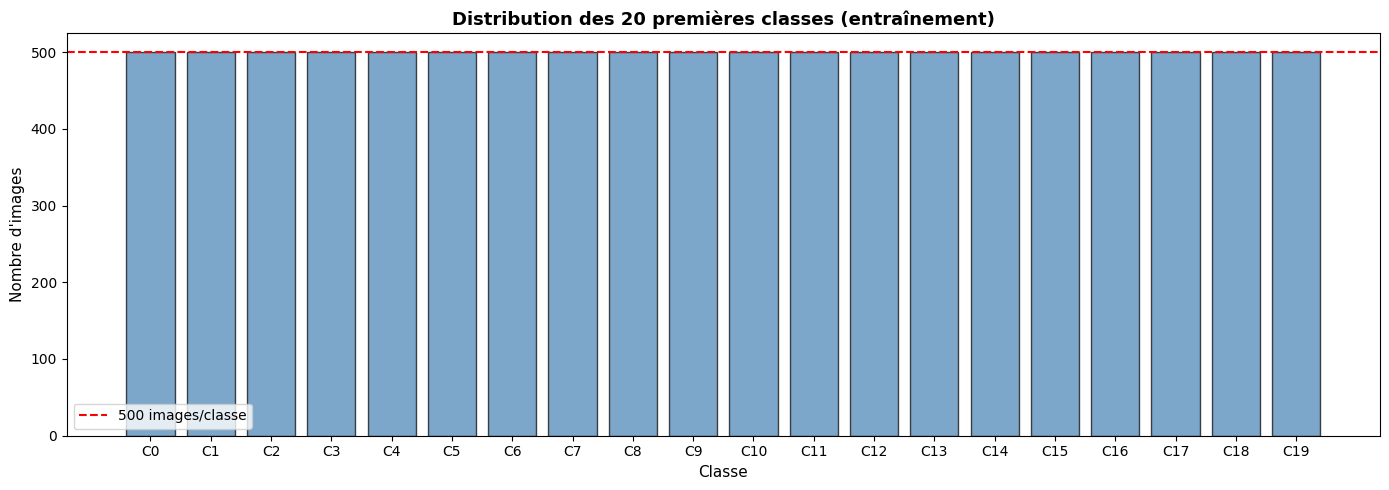

In [7]:
# vérification de l'équilibre des classes (on s'attend à 500 images par classe)
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(14, 5))
plt.bar(range(20), counts[:20], alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Classe', fontsize=11)
plt.ylabel("Nombre d'images", fontsize=11)
plt.title('Distribution des 20 premières classes (entraînement)', fontsize=13, fontweight='bold')
plt.xticks(range(20), [f"C{i}" for i in range(20)])
plt.axhline(y=500, color='red', linestyle='--', label='500 images/classe')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# normalisation des pixels entre 0 et 1
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

<a id='section3'></a>
## 3. Modèle MLP (Multi-Layer Perceptron)

### Architecture MLP
- **Entrée** : 3072 neurones (32×32×3 pixels aplatis)
- **Couche cachée 1** : 1024 neurones + ReLU + Dropout(0.4)
- **Couche cachée 2** : 512 neurones + ReLU + Dropout(0.4)
- **Couche cachée 3** : 256 neurones + ReLU + Dropout(0.3)
- **Couche de sortie** : 100 neurones + Softmax

### Caractéristiques
- Images aplaties (perte de structure spatiale)
- Architecture fully-connected
- Dropout élevé pour éviter l'overfitting

In [9]:
# le MLP attend un vecteur 1D, on aplatit les images
X_train_mlp = X_train_normalized.reshape(-1, 32*32*3)
X_test_mlp = X_test_normalized.reshape(-1, 32*32*3)

In [10]:
mlp_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(100, activation='softmax')
], name='MLP_CIFAR100')

mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

E0000 00:00:1777293286.486758  119670 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "MLP_CIFAR100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,828,580 (14.60 MB)

 Trainable params: 3,828,580 (14.60 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# early stopping pour éviter l'overfitting + réduction du lr si on stagne
mlp_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

In [12]:
mlp_history = mlp_model.fit(
    X_train_mlp, y_train,
    batch_size=128,
    epochs=30,
    validation_split=0.2,
    callbacks=mlp_callbacks,
    verbose=1
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.0198 - loss: 4.5306 - val_accuracy: 0.0534 - val_loss: 4.2551 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.0198 - loss: 4.5306 - val_accuracy: 0.0534 - val_loss: 4.2551 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.0442 - loss: 4.2518 - val_accuracy: 0.0659 - val_loss: 4.1374 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.0442 - loss: 4.2518 - val_accuracy: 0.0659 - val_loss: 4.1374 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.0564 - loss: 4.1364 - val_accuracy: 0.0836 - val_loss: 4.0524 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.0564 - loss: 4.1364 - val_accuracy: 0.0836 - val_loss: 4.0524 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.0636 - l

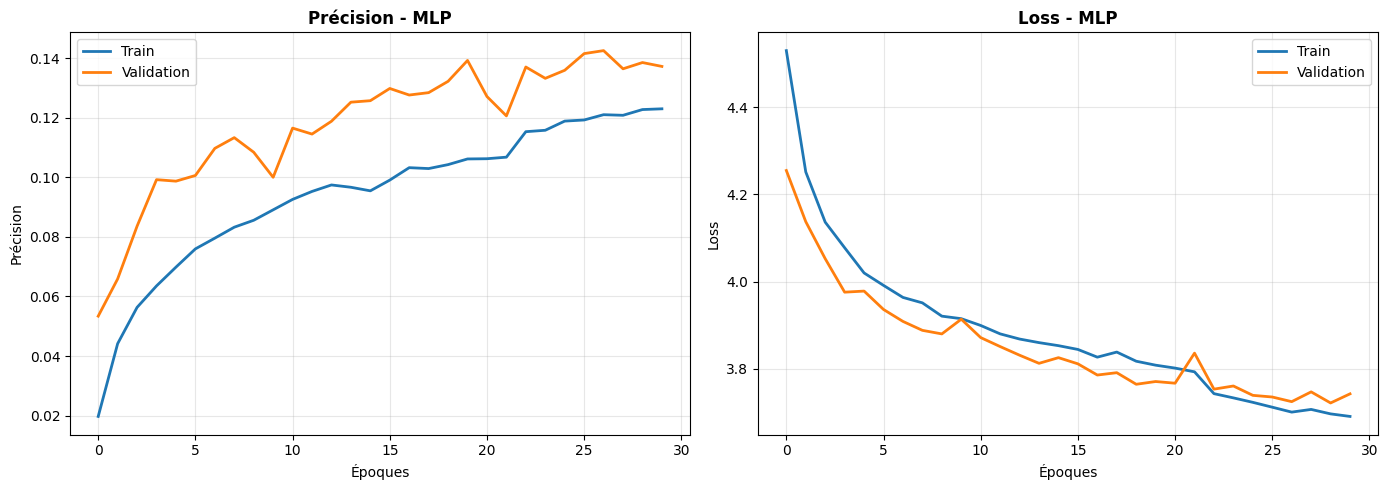

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(mlp_history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('Précision')
axes[0].set_title('Précision - MLP', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(mlp_history.history['loss'], label='Train', linewidth=2)
axes[1].plot(mlp_history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss - MLP', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
mlp_loss, mlp_acc = mlp_model.evaluate(X_test_mlp, y_test, verbose=0)
print(f"MLP — Accuracy : {mlp_acc*100:.2f}%  |  Loss : {mlp_loss:.4f}")

MLP — Accuracy : 14.49%  |  Loss : 3.7125


<a id='section4'></a>
## 4. Modèle CNN (Convolutional Neural Network)

### Architecture CNN
- **Bloc Convolutif 1** : Conv2D(64) → BN → ReLU → Conv2D(64) → BN → ReLU → MaxPooling → Dropout(0.2)
- **Bloc Convolutif 2** : Conv2D(128) → BN → ReLU → Conv2D(128) → BN → ReLU → MaxPooling → Dropout(0.3)
- **Bloc Convolutif 3** : Conv2D(256) → BN → ReLU → Conv2D(256) → BN → ReLU → MaxPooling → Dropout(0.3)
- **Flatten**
- **Dense 1** : 512 neurones + BN + ReLU + Dropout(0.4)
- **Dense 2** : 256 neurones + BN + ReLU + Dropout(0.4)
- **Sortie** : 100 neurones + Softmax

### Avantages
- `BatchNormalization` après chaque convolution → stabilise les gradients et accélère la convergence
- Extraction automatique de features hiérarchiques
- Préservation de la structure spatiale des images
- Invariance par translation grâce au MaxPooling
- Moins de paramètres que le MLP équivalent

In [15]:
X_train_cnn = X_train_normalized
X_test_cnn = X_test_normalized

In [16]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),
    layers.Dense(100, activation='softmax')
], name='CNN_CIFAR100')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "CNN_CIFAR100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 256)      │             

 Total params: 3,406,756 (13.00 MB)

 Trainable params: 3,403,428 (12.98 MB)

 Non-trainable params: 3,328 (13.00 KB)

In [17]:
# augmentation de données pour améliorer la généralisation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
], name='data_augmentation')

In [18]:
cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

In [19]:
def augment_data(images, labels):
    images = data_augmentation(images, training=True)
    return images, labels

# split manuel train/val pour pouvoir appliquer l'augmentation uniquement sur le train
train_size = int(0.8 * len(X_train_cnn))
indices = np.random.permutation(len(X_train_cnn))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

X_train_split = X_train_cnn[train_indices]
y_train_split = y_train[train_indices]
X_val_split = X_train_cnn[val_indices]
y_val_split = y_train[val_indices]

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_split, y_train_split))
train_dataset = train_dataset.shuffle(1024).batch(64).map(augment_data, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val_split, y_val_split))
val_dataset = val_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

In [20]:
cnn_history = cnn_model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=cnn_callbacks,
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 377s 587ms/step - accuracy: 0.0735 - loss: 4.1389 - val_accuracy: 0.1339 - val_loss: 3.6969 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 377s 587ms/step - accuracy: 0.0735 - loss: 4.1389 - val_accuracy: 0.1339 - val_loss: 3.6969 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 377s 603ms/step - accuracy: 0.1456 - loss: 3.5928 - val_accuracy: 0.1488 - val_loss: 3.7115 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 377s 603ms/step - accuracy: 0.1456 - loss: 3.5928 - val_accuracy: 0.1488 - val_loss: 3.7115 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 381s 609ms/step - accuracy: 0.1920 - loss: 3.3197 - val_accuracy: 0.2293 - val_loss: 3.1061 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 381s 609ms/step - accuracy: 0.1920 - loss: 3.3197 - val_accuracy: 0.2293 - val_loss: 3.1061 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 380s 607ms/step - accura

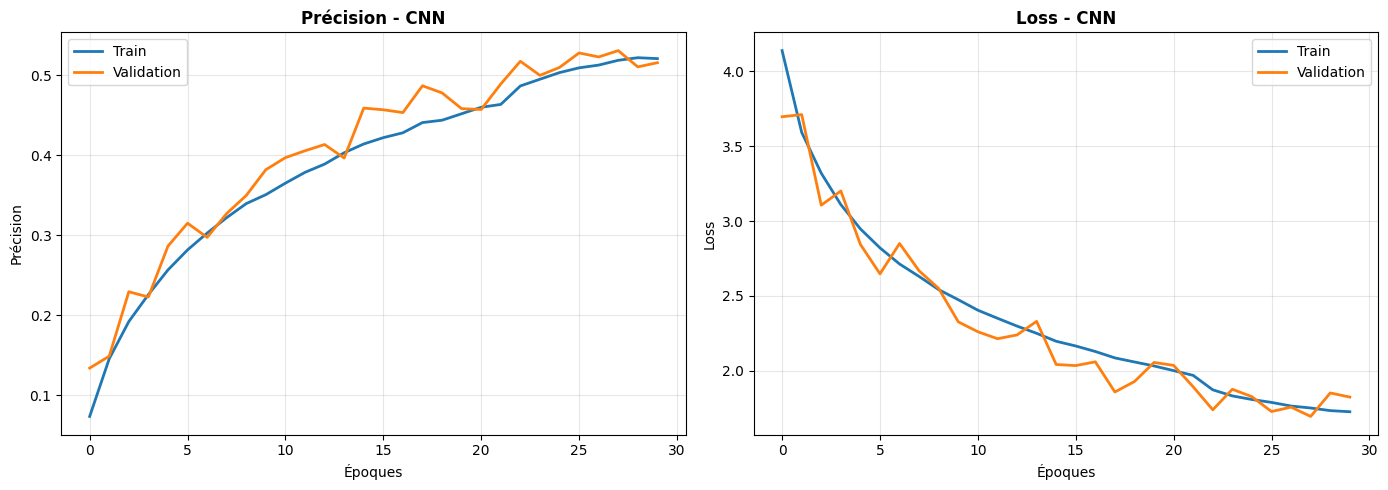

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('Précision')
axes[0].set_title('Précision - CNN', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(cnn_history.history['loss'], label='Train', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss - CNN', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"CNN — Accuracy : {cnn_acc*100:.2f}%  |  Loss : {cnn_loss:.4f}")

CNN — Accuracy : 54.73%  |  Loss : 1.6512


<a id='section5'></a>
## 5. Comparaison et analyse des résultats

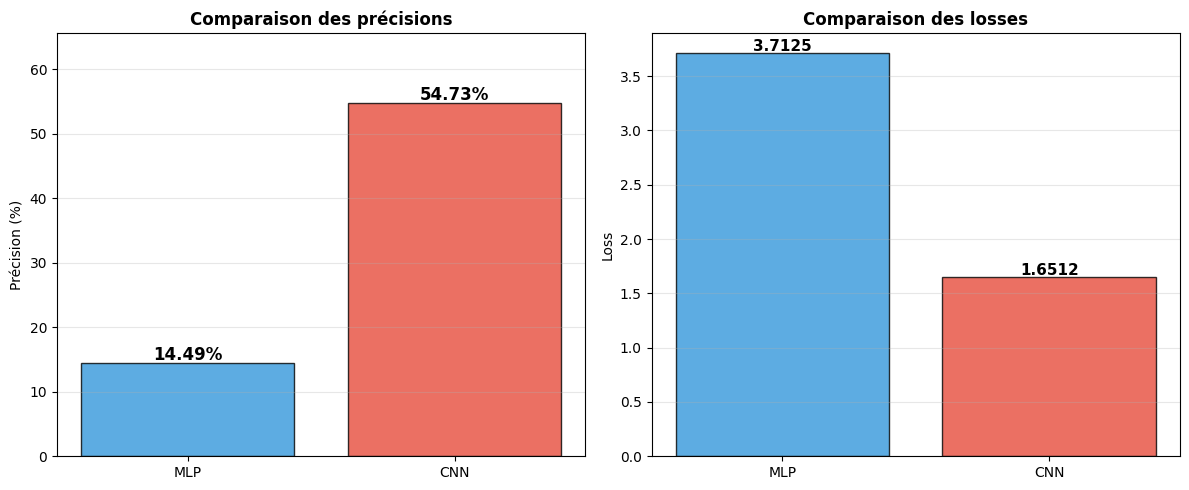

Gain CNN vs MLP : +40.24 points  (+277.7%)


In [23]:
models_names = ['MLP', 'CNN']
accuracies = [mlp_acc * 100, cnn_acc * 100]
losses = [mlp_loss, cnn_loss]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#3498db', '#e74c3c']
bars = axes[0].bar(models_names, accuracies, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Précision (%)')
axes[0].set_title('Comparaison des précisions', fontweight='bold')
axes[0].set_ylim([0, max(accuracies) * 1.2])
axes[0].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.5, f'{acc:.2f}%',
                ha='center', fontsize=12, fontweight='bold')

bars = axes[1].bar(models_names, losses, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Loss')
axes[1].set_title('Comparaison des losses', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, loss in zip(bars, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, loss + 0.02, f'{loss:.4f}',
                ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Gain CNN vs MLP : {(cnn_acc - mlp_acc)*100:+.2f} points  ({((cnn_acc - mlp_acc)/mlp_acc)*100:+.1f}%)")

In [24]:
# prédictions sur un sous-ensemble pour la visualisation
mlp_pred = np.argmax(mlp_model.predict(X_test_mlp[:1000], verbose=0), axis=1)
cnn_pred = np.argmax(cnn_model.predict(X_test_cnn[:1000], verbose=0), axis=1)
y_test_sample = y_test[:1000]

In [25]:
# la top-5 accuracy est une métrique classique sur les datasets à beaucoup de classes
def top_k_accuracy(y_true, y_pred_proba, k=5):
    top_k = np.argsort(y_pred_proba, axis=1)[:, -k:]
    return np.mean([y_true[i] in top_k[i] for i in range(len(y_true))])

mlp_pred_proba = mlp_model.predict(X_test_mlp, verbose=0)
cnn_pred_proba = cnn_model.predict(X_test_cnn, verbose=0)

mlp_top5 = top_k_accuracy(y_test, mlp_pred_proba)
cnn_top5 = top_k_accuracy(y_test, cnn_pred_proba)

print(f"Top-5 Accuracy — MLP : {mlp_top5*100:.2f}%  |  CNN : {cnn_top5*100:.2f}%")

Top-5 Accuracy — MLP : 37.51%  |  CNN : 82.98%


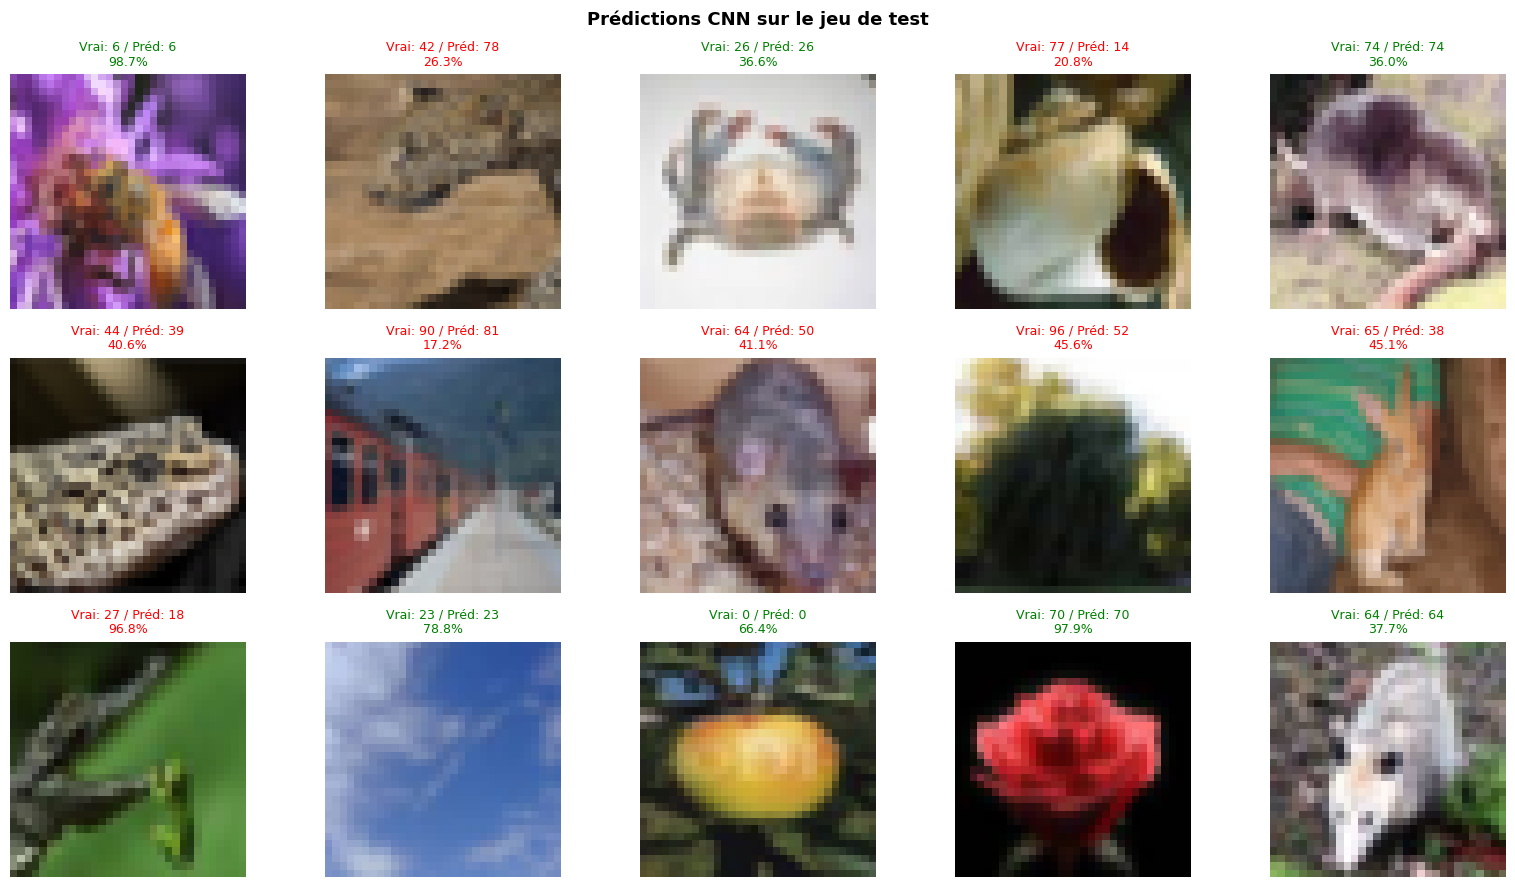

In [26]:
fig, axes = plt.subplots(3, 5, figsize=(16, 9))
indices = np.random.choice(len(X_test), 15, replace=False)

for idx, ax in zip(indices, axes.flat):
    ax.imshow(X_test[idx])
    true_label = y_test[idx]
    pred_label = np.argmax(cnn_pred_proba[idx])
    confidence = np.max(cnn_pred_proba[idx]) * 100
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Vrai: {true_label} / Préd: {pred_label}\n{confidence:.1f}%",
                fontsize=9, color=color)
    ax.axis('off')

plt.suptitle('Prédictions CNN sur le jeu de test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
print("Récapitulatif des résultats\n")
print(f"{'Modèle':<10} {'Paramètres':>15} {'Top-1':>8} {'Top-5':>8} {'Loss':>8}")
print("-" * 52)
print(f"{'MLP':<10} {mlp_model.count_params():>15,} {mlp_acc*100:>7.2f}% {mlp_top5*100:>7.2f}% {mlp_loss:>8.4f}")
print(f"{'CNN':<10} {cnn_model.count_params():>15,} {cnn_acc*100:>7.2f}% {cnn_top5*100:>7.2f}% {cnn_loss:>8.4f}")
print("-" * 52)
print(f"\nGain CNN vs MLP : +{(cnn_acc - mlp_acc)*100:.2f} pts (Top-1)  |  +{(cnn_top5 - mlp_top5)*100:.2f} pts (Top-5)")

Récapitulatif des résultats

Modèle          Paramètres    Top-1    Top-5     Loss
----------------------------------------------------
MLP              3,828,580   14.49%   37.51%   3.7125
CNN              3,406,756   54.73%   82.98%   1.6512
----------------------------------------------------

Gain CNN vs MLP : +40.24 pts (Top-1)  |  +45.47 pts (Top-5)


<a id='section6'></a>
## 6. Conclusion

Ce projet a comparé deux architectures de deep learning — MLP et CNN — sur le dataset CIFAR-100, un benchmark reconnu pour sa difficulté : 100 classes avec seulement 500 images d'entraînement par classe.

### Résultats obtenus

| Modèle | Top-1 Accuracy | Top-5 Accuracy | Loss |
|--------|---------------|----------------|------|
| MLP    | 14.49 %       | 37.51 %        | 3.71 |
| CNN    | **54.73 %**   | **82.98 %**    | **1.65** |

Le **CNN surpasse le MLP de +40 points** en Top-1 et +45 points en Top-5, ce qui confirme l'importance de la structure spatiale pour la classification d'images.

### Analyse

Le MLP traite chaque pixel indépendamment après avoir aplati l'image en vecteur 1D : il perd toute information de voisinage et de texture, ce qui explique ses performances limitées à ~14%. C'est néanmoins cohérent avec la littérature pour un MLP entraîné from scratch sur CIFAR-100.

Le CNN, grâce aux convolutions, extrait automatiquement des features hiérarchiques (contours → textures → formes → objets). L'ajout de `BatchNormalization` après chaque couche a été essentiel : sans lui, les gradients s'annulaient dans le réseau profond, bloquant complètement l'apprentissage. L'augmentation de données (flip, rotation, zoom) a limité l'overfitting et amélioré la généralisation.

### Perspectives

Pour aller plus loin, les pistes les plus prometteuses sont le **transfer learning** à partir de modèles pré-entraînés (ResNet50, EfficientNet) qui permettent d'atteindre 75-80% sur CIFAR-100, et des techniques d'augmentation avancées comme **Mixup** ou **CutMix**.

---
*Dataset : CIFAR-100 — 50 000 images d'entraînement / 10 000 de test / 100 classes*